Introduction :
The objective of this lab is to utilize techniques of data visualization, preprocessing, and statistical analysis using Python in Google Colab/Jupyter Notebook. A dataset on sales has been created which contains information about products, categories of products, quantity, sales, profit, and rating of the customers. The analysis has been done using Pandas, NumPy, Matplotlib, and Scikit-learn. The analysis will involve exploration of the dataset, visualization of the data, handling of missing values, detecting and handling of outliers, reduction of the dataset, scaling of numerical data, discretization of the continuous variables, and finally, statistical analysis of the dataset. These are the basic techniques which will help in preparation of the raw data for analysis. Step 1: Data Collection A sales dataset has been created which consists of 20 observations and 6 variables. These variables include Product, Category, Quantity, Sales, Profit, and Rating.

These are the required libraries which is imported first. import pandas as pd import numpy as np import matplotlib.pyplot as plt Furthermore, five records have been displayed.

Step 1: Data Collection

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df.head()

,Product,Category,Quantity,Sales,Profit,Rating
0,Laptop,Electronics,5,5000,1000,4.5
1,Phone,Electronics,10,7000,1400,4.3
2,Tablet,Electronics,7,3500,700,4.1
3,Monitor,Electronics,4,2000,400,4.0
4,Keyboard,Accessories,15,750,150,4.6


Step 2: Data Visualization


2.1 Histogram – Distribution of Sales

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Product': [
        'Laptop', 'Phone', 'Tablet', 'Monitor', 'Keyboard',
        'Mouse', 'Printer', 'Camera', 'Speaker', 'Headphones',
        'Laptop', 'Phone', 'Tablet', 'Monitor', 'Keyboard',
        'Mouse', 'Printer', 'Camera', 'Speaker', 'Headphones'
    ],

    'Category': [
        'Electronics', 'Electronics', 'Electronics', 'Electronics', 'Accessories',
        'Accessories', 'Electronics', 'Electronics', 'Accessories', 'Accessories',
        'Electronics', 'Electronics', 'Electronics', 'Electronics', 'Accessories',
        'Accessories', 'Electronics', 'Electronics', 'Accessories', 'Accessories'
    ],

    'Quantity': [
        5, 10, 7, 4, 15,
        20, 3, 6, 12, 14,
        8, 11, 5, 7, 18,
        25, 4, 5, 13, 16
    ],

    'Sales': [
        5000, 7000, 3500, 2000, 750,
        500, 1800, 4200, 1200, 1400,
        8000, 7700, 2500, 3500, 900,
        625, 2400, 3500, 1300, 16000
    ],

    'Profit': [
        1000, 1400, 700, 400, 150,
        100, 360, 840, 240, 280,
        1600, 1540, 500, 700, 180,
        125, 480, 700, 260, 3200
    ],

    'Rating': [
        4.5, 4.3, 4.1, 4.0, 4.6,
        np.nan, 3.9, 4.7, 4.2, 4.4,
        4.6, 4.5, np.nan, 4.1, 4.3,
        4.0, 3.8, 4.8, 4.2, 4.5
    ]
}

df = pd.DataFrame(data)

df.to_csv('sales_data.csv', index=False)

print("Dataset created successfully!")

Dataset created successfully!


In [11]:
df.head()

,Product,Category,Quantity,Sales,Profit,Rating
0,Laptop,Electronics,5,5000,1000,4.5
1,Phone,Electronics,10,7000,1400,4.3
2,Tablet,Electronics,7,3500,700,4.1
3,Monitor,Electronics,4,2000,400,4.0
4,Keyboard,Accessories,15,750,150,4.6


Analysis: It can be seen from the histogram that there are many sales observations falling in the lower and middle range of sales. On the other hand, there are only few sales observations having high sales values. Especially, it can be noticed that the observation around $16,000 is quite separate from others.

Step 2: Data Visualization

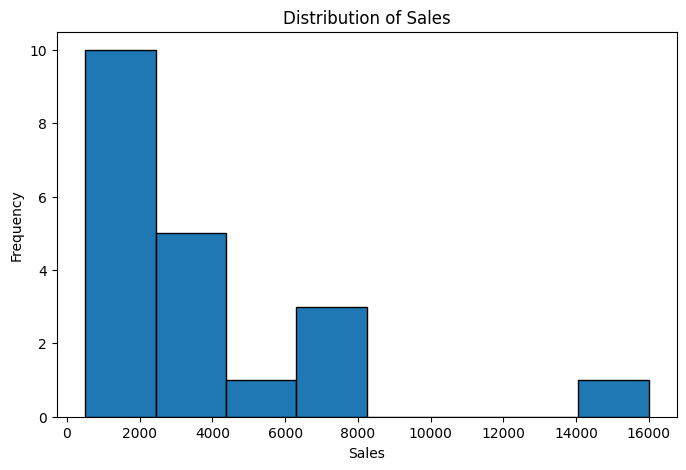

In [8]:
df.head()
plt.figure(figsize=(8, 5))

plt.hist(df['Sales'], bins=8, edgecolor='black')

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

### Scatter Plot Analysis

The scatter plot shows a positive relationship between sales and profit. As sales increase, profit generally increases as well. This indicates that products generating higher sales tend to produce higher profits.

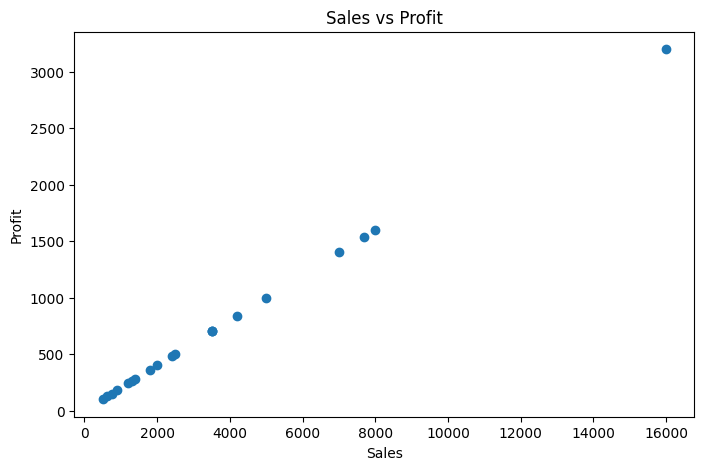

In [4]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Sales'], df['Profit'])

plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')

plt.show()

As can be seen from the scatter plot above, there is a very strong positive relationship between sales and profit. As the sales increase, the profit also increases. The observations follow almost linear pattern since the profit values in this dataset are proportional to sales. Thus, products making more sales make more profits as well.

**Data Preprocessing**

3.1 Detecting and handeling missing values

In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Product     0
Category    0
Quantity    0
Sales       0
Profit      0
Rating      2
dtype: int64


In [7]:
df[df.isnull().any(axis=1)]

,Product,Category,Quantity,Sales,Profit,Rating
5,Mouse,Accessories,20,500,100,NaN
12,Tablet,Electronics,5,2500,500,NaN


The existence of missing values in the dataset was examined by applying the isnull().sum() function. It was found that the Rating variable had two missing values, whereas there were no missing values in other variables. These missing ratings were imputed by calculating their mean value of about 4.31. Imputation by means of the mean value was chosen as it was applied to a numerical variable. After imputing the missing values, the presence of missing values in the dataset was examined again, and it turned out that there were no missing values in all variable.

3.2 Outliner detection and removal

In [12]:
mean_rating = df['Rating'].mean()

print("Mean Rating:", mean_rating)

df['Rating'] = df['Rating'].fillna(mean_rating)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Mean Rating: 4.3055555555555545

Missing values after cleaning:
Product     0
Category    0
Quantity    0
Sales       0
Profit      0
Rating      0
dtype: int64


The IQR method was used to find outliers in the Sales column. Q1 = 1275, Q3 = 4400, and IQR = 3125. Using the lower and upper bounds calculated, all values of the Sales greater than 9087.5 were found as outliers. The value of Sales of 16000 was an outlier and was therefore dropped. The total number of rows in the dataset was decreased from 20 to 19 as a result of dropping the Sales value.

In [13]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 1275.0
Q3: 4400.0
IQR: 3125.0
Lower Bound: -3412.5
Upper Bound: 9087.5


3.3 Data reduction

In [ ]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Sales'] < lower_bound) |
    (df['Sales'] > upper_bound)
]

print("Identified Outliers:")
outliers

Identified Outliers:


,Product,Category,Quantity,Sales,Profit,Rating
19,Headphones,Accessories,16,16000,3200,4.5


3.4 Data scaling and decentralization

In [15]:
df_no_outliers = df[
    (df['Sales'] >= lower_bound) &
    (df['Sales'] <= upper_bound)
].copy()

print("Original dataset size:", df.shape)
print("Dataset size after removing outliers:", df_no_outliers.shape)

df_no_outliers

Original dataset size: (20, 6)
Dataset size after removing outliers: (19, 6)


,Product,Category,Quantity,Sales,Profit,Rating
0,Laptop,Electronics,5,5000,1000,4.500000
1,Phone,Electronics,10,7000,1400,4.300000
2,Tablet,Electronics,7,3500,700,4.100000
3,Monitor,Electronics,4,2000,400,4.000000
4,Keyboard,Accessories,15,750,150,4.600000
5,Mouse,Accessories,20,500,100,4.305556
6,Printer,Electronics,3,1800,360,3.900000
7,Camera,Electronics,6,4200,840,4.700000
8,Speaker,Accessories,12,1200,240,4.200000
9,Headphones,Accessories,14,1400,280,4.400000


In [16]:
print("Dataset before reduction:")
print("Shape:", df_no_outliers.shape)

df_no_outliers.head()

Dataset before reduction:
Shape: (19, 6)


,Product,Category,Quantity,Sales,Profit,Rating
0,Laptop,Electronics,5,5000,1000,4.5
1,Phone,Electronics,10,7000,1400,4.3
2,Tablet,Electronics,7,3500,700,4.1
3,Monitor,Electronics,4,2000,400,4.0
4,Keyboard,Accessories,15,750,150,4.6


In [17]:
sample_df = df_no_outliers.sample(
    frac=0.70,
    random_state=42
)

print("Original size:", df_no_outliers.shape)
print("Sampled size:", sample_df.shape)

sample_df

Original size: (19, 6)
Sampled size: (13, 6)


,Product,Category,Quantity,Sales,Profit,Rating
0,Laptop,Electronics,5,5000,1000,4.500000
5,Mouse,Accessories,20,500,100,4.305556
11,Phone,Electronics,11,7700,1540,4.500000
1,Phone,Electronics,10,7000,1400,4.300000
8,Speaker,Accessories,12,1200,240,4.200000
16,Printer,Electronics,4,2400,480,3.800000
3,Monitor,Electronics,4,2000,400,4.000000
13,Monitor,Electronics,7,3500,700,4.100000
15,Mouse,Accessories,25,625,125,4.000000
17,Camera,Electronics,5,3500,700,4.800000


Step 4: Statistical Analysis
4.1 General Information on Data

In [18]:
reduced_df = sample_df.drop(columns=['Rating'])

print("Columns before reduction:")
print(sample_df.columns.tolist())

print("\nColumns after reduction:")
print(reduced_df.columns.tolist())

reduced_df.head()

Columns before reduction:
['Product', 'Category', 'Quantity', 'Sales', 'Profit', 'Rating']

Columns after reduction:
['Product', 'Category', 'Quantity', 'Sales', 'Profit']


,Product,Category,Quantity,Sales,Profit
0,Laptop,Electronics,5,5000,1000
5,Mouse,Accessories,20,500,100
11,Phone,Electronics,11,7700,1540
1,Phone,Electronics,10,7000,1400
8,Speaker,Accessories,12,1200,240


4.2 Measures of Central Tendency

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df_no_outliers.copy()

print("Sales before scaling:")
print(df_scaled[['Sales']].head())

Sales before scaling:
   Sales
0   5000
1   7000
2   3500
3   2000
4    750


In [20]:
df_scaled['Sales_Scaled'] = scaler.fit_transform(
    df_scaled[['Sales']]
)

print("Sales before and after scaling:")

df_scaled[['Sales', 'Sales_Scaled']].head(10)

Sales before and after scaling:


,Sales,Sales_Scaled
0,5000,0.600000
1,7000,0.866667
2,3500,0.400000
3,2000,0.200000
4,750,0.033333
5,500,0.000000
6,1800,0.173333
7,4200,0.493333
8,1200,0.093333
9,1400,0.120000


4.3 Measures of Dispersion

In [21]:
df_scaled['Sales_Category'] = pd.cut(
    df_scaled['Sales'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

df_scaled[['Sales', 'Sales_Scaled', 'Sales_Category']].head(10)

,Sales,Sales_Scaled,Sales_Category
0,5000,0.600000,Medium
1,7000,0.866667,High
2,3500,0.400000,Medium
3,2000,0.200000,Low
4,750,0.033333,Low
5,500,0.000000,Low
6,1800,0.173333,Low
7,4200,0.493333,Medium
8,1200,0.093333,Low
9,1400,0.120000,Low


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Product   20 non-null     object 
 1   Category  20 non-null     object 
 2   Quantity  20 non-null     int64  
 3   Sales     20 non-null     int64  
 4   Profit    20 non-null     int64  
 5   Rating    20 non-null     float64
dtypes: float64(1), int64(3), object(2)
memory usage: 1.1+ KB


In [23]:
df.describe()

,Quantity,Sales,Profit,Rating
count,20.000000,20.000000,20.000000,20.000000
mean,10.400000,3688.750000,737.750000,4.305556
std,6.116414,3712.678092,742.535618,0.272362
min,3.000000,500.000000,100.000000,3.800000
25%,5.000000,1275.000000,255.000000,4.100000
50%,9.000000,2450.000000,490.000000,4.302778
75%,14.250000,4400.000000,880.000000,4.500000
max,25.000000,16000.000000,3200.000000,4.800000


In [24]:
minimum = df['Sales'].min()
maximum = df['Sales'].max()
mean = df['Sales'].mean()
median = df['Sales'].median()
mode = df['Sales'].mode()[0]

print("Sales Central Tendency Measures")
print("--------------------------------")
print("Minimum:", minimum)
print("Maximum:", maximum)
print("Mean:", mean)
print("Median:", median)
print("Mode:", mode)

Sales Central Tendency Measures
--------------------------------
Minimum: 500
Maximum: 16000
Mean: 3688.75
Median: 2450.0
Mode: 3500


In [25]:
sales_range = df['Sales'].max() - df['Sales'].min()

Q1 = df['Sales'].quantile(0.25)
Q2 = df['Sales'].quantile(0.50)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

variance = df['Sales'].var()
std_dev = df['Sales'].std()

print("Sales Dispersion Measures")
print("-------------------------")
print("Range:", sales_range)
print("Q1:", Q1)
print("Q2 (Median):", Q2)
print("Q3:", Q3)
print("IQR:", IQR)
print("Variance:", variance)
print("Standard Deviation:", std_dev)

Sales Dispersion Measures
-------------------------
Range: 15500
Q1: 1275.0
Q2 (Median): 2450.0
Q3: 4400.0
IQR: 3125.0
Variance: 13783978.618421054
Standard Deviation: 3712.6780924854033


In [26]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

correlation_matrix

,Quantity,Sales,Profit,Rating
Quantity,1.000000,-0.084330,-0.084330,0.043705
Sales,-0.084330,1.000000,1.000000,0.373936
Profit,-0.084330,1.000000,1.000000,0.373936
Rating,0.043705,0.373936,0.373936,1.000000


4.4 Correlation Analysis The correlation matrix was computed for all numerical variables.

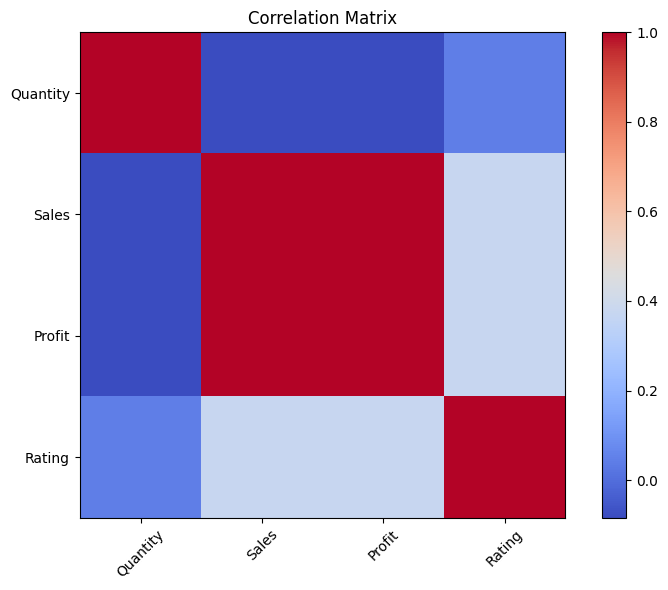

In [27]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Matrix')
plt.tight_layout()

plt.show()

Conclusion

Some of the techniques that have been used during the process of preparing and exploring data have been shown through this lab experiment. Creation and analysis of a sales dataset having the fields such as product, category, quantity, sales, profit, and rating has been done using Python. Visualization revealed that Sales variable was right-skewed and that there was a strong positive relationship between Sales and Profit. Two missing values for the Rating field have been observed during preprocessing and filled up with the mean rating. Outlier value of 16,000 Sales has been identified using IQR and removal of that observation led to dropping of one value from the data set making it 20 to 19. Data Reduction was carried out through 70% random sampling and dimension elimination. Min-Max Scaling has been applied to Sales values and converted them to the range of 0 to 1, while Sales have been categorized into Low, Medium, and High using Discretization.